# PyPSA-Sudan · Regional visual atlas
**19 model regions · legacy August 2024 illustration · 168 model hours**

Explore native PyPSA pie maps, regional generation mixes, transfer flows and dispatch.
These are model regions, **not administrative-state polygons**. The plant availability and disconnected corridors belong to the earlier 2024 example; this notebook is not a 2022 regional reconstruction.

The selected research reference remains **2022**: open [02_reference_2022.ipynb](02_reference_2022.ipynb) for that national benchmark. Regional 2022 statistics are still missing.

Outputs are saved below. To update them, select the **Python (pypsa)** kernel and run all cells. Change `SCENARIO` or `REGION` in the indicated cells to explore another case. No optimization is run here; the notebook reads solved networks.

In [1]:
from pathlib import Path
import json
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display
import pypsa

logging.getLogger("pypsa").setLevel(logging.ERROR)
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "config/reference_2022.json").exists())
FIG = ROOT / "results/notebook_figures"
FIG.mkdir(parents=True, exist_ok=True)
COLORS = {"hydro":"#258eaa", "oil":"#dd9a50", "diesel":"#986445",
          "coal":"#667085", "combustible":"#dd9a50", "other":"#73a65a",
          "import":"#8a70b7", "imports":"#8a70b7", "unserved":"#d75460"}
LABELS = {"hydro":"Hydro", "oil":"Oil", "diesel":"Diesel", "coal":"Coal",
          "combustible":"Combustible fuels", "other":"Other", "import":"Imports",
          "imports":"Imports", "unserved":"Unserved load"}
plt.rcParams.update({"figure.dpi":110, "font.size":10, "axes.spines.top":False,
                     "axes.spines.right":False, "axes.titleweight":"bold",
                     "axes.labelcolor":"#334155", "text.color":"#173347"})

def finish(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=170, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

def donut(ax, values, title, unit):
    values = values[values > 1e-8]
    total = values.sum()
    if total > 0:
        ax.pie(values, colors=[COLORS.get(c, "#8996a4") for c in values.index],
               startangle=90, counterclock=False, wedgeprops={"width":.34,"edgecolor":"white"})
        ax.text(0, 0, f"{total:,.1f}\n{unit}", ha="center", va="center", fontsize=11)
    else:
        ax.pie([1], colors=["#edf1f3"], wedgeprops={"width":.34,"edgecolor":"white"})
        ax.text(0, 0, "No local\ngeneration", ha="center", va="center", fontsize=9, color="#6b7280")
    ax.set_title(title, fontsize=11, pad=8)

## 1 · Choose a solved regional scenario
Available cases: `baseline_2024`, `high_demand`, `low_hydro`, `weak_transmission`, `grid_repair`, `thermal_recovery`.
All use the legacy 2024 model. Physical generation excludes imports and the artificial shortage generators.

In [2]:
SCENARIO = "baseline_2024"  # Change this, then rerun the following cells.
n = pypsa.Network(ROOT / "results" / SCENARIO / "network.nc")
regions = pd.read_csv(ROOT / "data/curated/buses.csv").set_index("bus")
for carrier in n.carriers.index:
    n.carriers.loc[carrier, "color"] = COLORS.get(carrier, "#8996a4")
g = n.generators
physical = ~g.carrier.isin(["unserved", "import"])
energy_mwh = n.generators_t.p.mul(n.snapshot_weightings.generators, axis=0).sum()
capacity = g.loc[physical].groupby(["bus", "carrier"]).p_nom.sum()
generation = (g.loc[physical].assign(energy_mwh=energy_mwh)
              .groupby(["bus", "carrier"]).energy_mwh.sum())
assert np.isclose(capacity.sum(), g.loc[physical, "p_nom"].sum())
assert np.isclose(generation.sum(), energy_mwh[physical].sum())
print(f"{SCENARIO}: {len(n.buses)} model regions; {len(n.snapshots)} hours; "
      f"{capacity.sum():,.1f} MW domestic nameplate")

## 2 · Native PyPSA capacity pie map
Circle area represents domestic nameplate MW; slices represent fuel/technology. Corridor width shows the **assumed** transfer limit. Dashed connectors are disabled corridors. Imports and shortage variables are excluded from capacity.

The map uses `n.plot.map(bus_size=...)` with a bus/carrier MultiIndex, following [PyPSA's plotting interface](https://docs.pypsa.org/v1.0.6/api/networks/plot/). The locally saved country boundary provides geographic context without a map download.

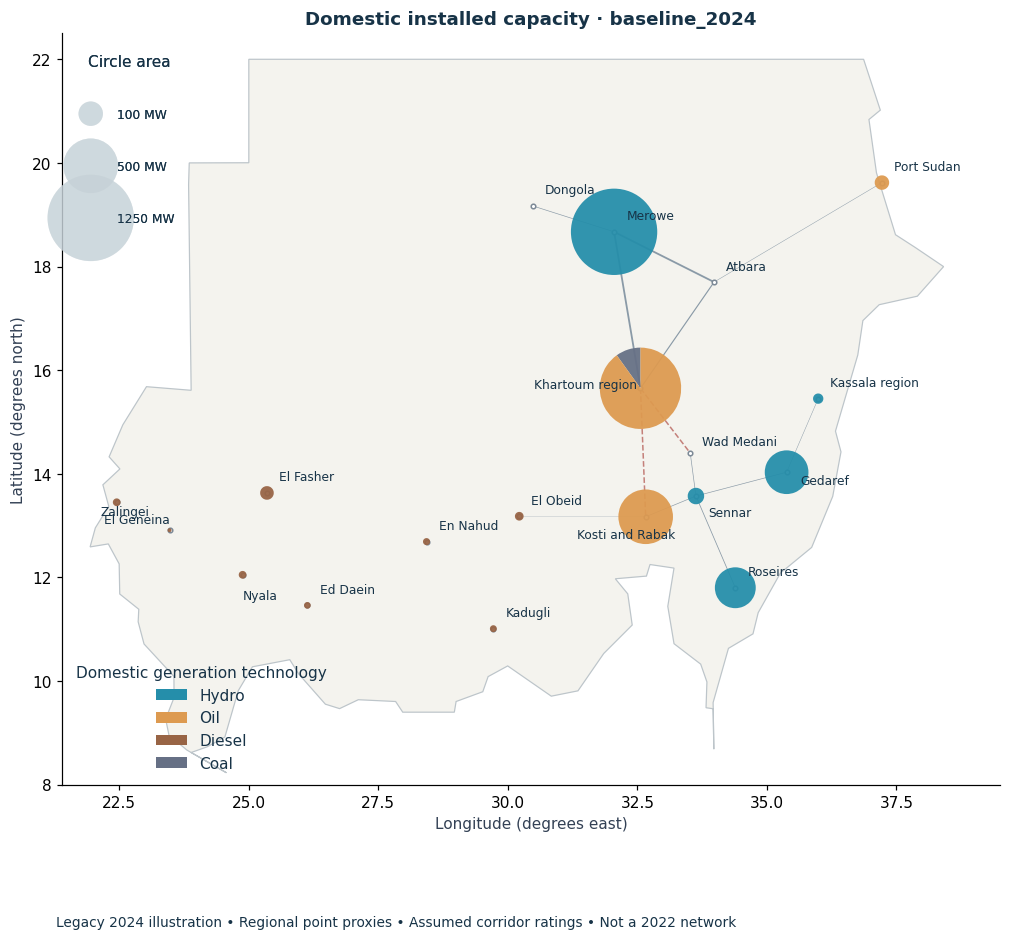

In [3]:
from pypsa.plot import add_legend_circles

def pie_map(values, scale, title, legend_sizes, unit, filename):
    fig, ax = plt.subplots(figsize=(11, 10))
    boundary = json.loads((ROOT / "data/processed/sudan_boundary.geojson").read_text(encoding="utf-8"))
    for feature in boundary["features"]:
        geom = feature["geometry"]
        polygons = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
        for polygon in polygons:
            xy = np.array(polygon[0])
            ax.fill(xy[:, 0], xy[:, 1], facecolor="#f4f3ee", edgecolor="#bdc5ca", linewidth=.8, zorder=0)
    ax.set_xlim(21.4, 39.5)
    ax.set_ylim(8.0, 22.5)
    ax.set_aspect("equal")
    ax.scatter(n.buses.x, n.buses.y, s=9, facecolors="white", edgecolors="#7c8996", zorder=2)
    positive = values[values > 1e-8]
    n.plot.map(ax=ax, geomap=False, bus_size=positive / scale,
               bus_color=COLORS, bus_alpha=.94, branch_components=["Link"],
               link_width=n.links.p_nom / 20000, link_color="#8a9aa7",
               boundaries=(21.4,39.5,8.0,22.5),
               auto_scale_branches=False)
    ax.set_xlim(21.4,39.5)
    ax.set_ylim(8.0,22.5)
    ax.set_axis_on()
    for row in n.links[n.links.p_nom == 0].itertuples():
        a, b = n.buses.loc[row.bus0], n.buses.loc[row.bus1]
        ax.plot([a.x,b.x],[a.y,b.y], "--", color="#c4807a", lw=1, zorder=1)
    offsets = {"Khartoum":(-70,0), "WadMedani":(8,5), "Sennar":(8,-13),
               "Kosti":(-45,-14), "Zalingei":(-45,10), "Nyala":(0,-16),
               "ElGeneina":(-8,-14), "Gedaref":(9,-8)}
    for name, row in n.buses.iterrows():
        ax.annotate(regions.loc[name,"label"], (row.x,row.y),
                    xytext=offsets.get(name,(8,8)), textcoords="offset points", fontsize=8, zorder=10)
    carriers = [c for c in COLORS if c in positive.index.get_level_values("carrier")]
    fuel_legend = ax.legend(handles=[Patch(facecolor=COLORS[c], label=LABELS[c]) for c in carriers],
                           title="Domestic generation technology", loc="lower left", frameon=False)
    ax.add_artist(fuel_legend)
    add_legend_circles(ax, sizes=np.array(legend_sizes)/scale,
                      labels=[f"{v:g} {unit}" for v in legend_sizes],
                      patch_kw={"facecolor":"#c6d2d8","alpha":.6},
                      legend_kw={"loc":"upper left","frameon":False,"title":"Circle area",
                                 "labelspacing":3.2,"borderpad":1.2,"fontsize":8})
    ax.set(title=title, xlabel="Longitude (degrees east)", ylabel="Latitude (degrees north)")
    fig.text(.12,.025,"Legacy 2024 illustration • Regional point proxies • Assumed corridor ratings • Not a 2022 network", fontsize=9)
    finish(fig, filename)

pie_map(capacity, 1800, f"Domestic installed capacity · {SCENARIO}", [100,500,1250], "MW",
        f"{SCENARIO}_capacity_map")

## 3 · Generation pie map
Circle area now represents domestic electricity **generated in each region** over the modelled week. This is not the electricity mix consumed there: electricity also moves between regions. Hollow points can receive power despite having no local generation.

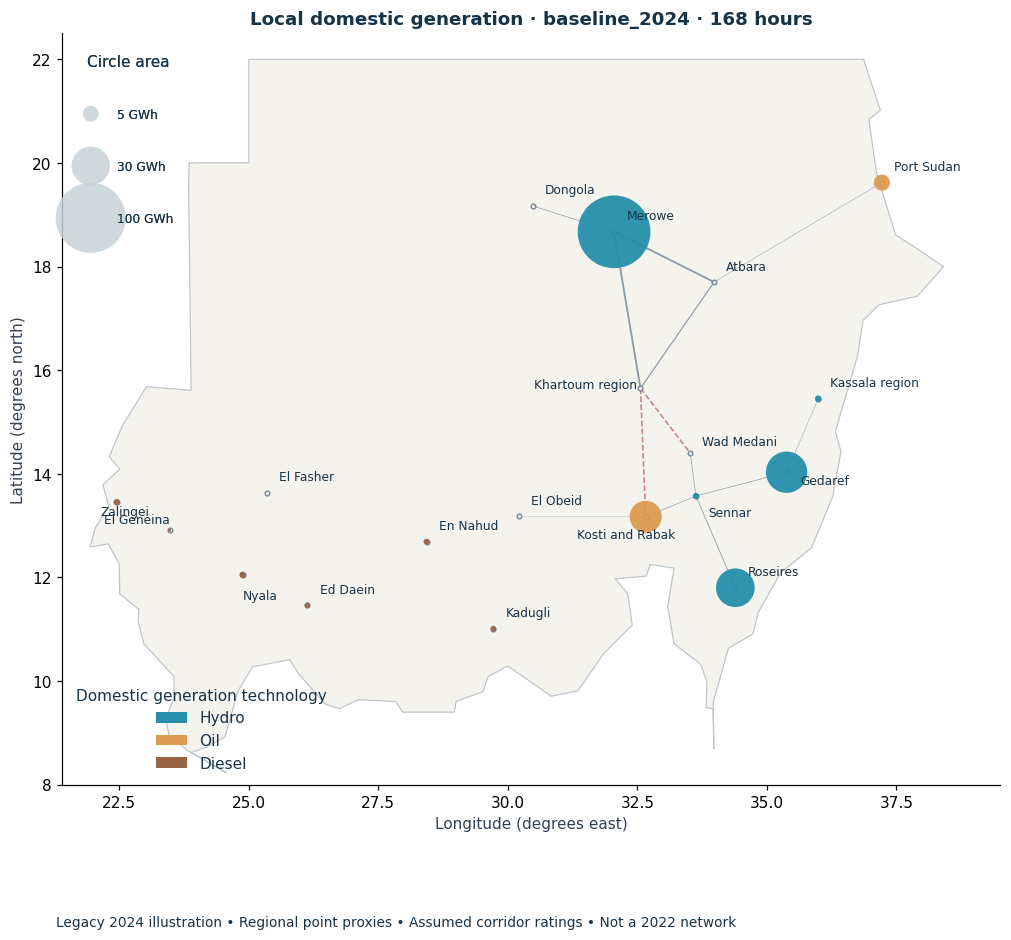

In [4]:
pie_map(generation / 1000, 220, f"Local domestic generation · {SCENARIO} · {len(n.snapshots)} hours",
        [5,30,100], "GWh", f"{SCENARIO}_generation_map")

## 4 · Every region: local generation mix
Each donut shows its own local production mix. Donuts have equal outer size so small systems remain readable; the centre gives the absolute GWh. Empty donuts mean no modelled local generation, not necessarily no electricity service.

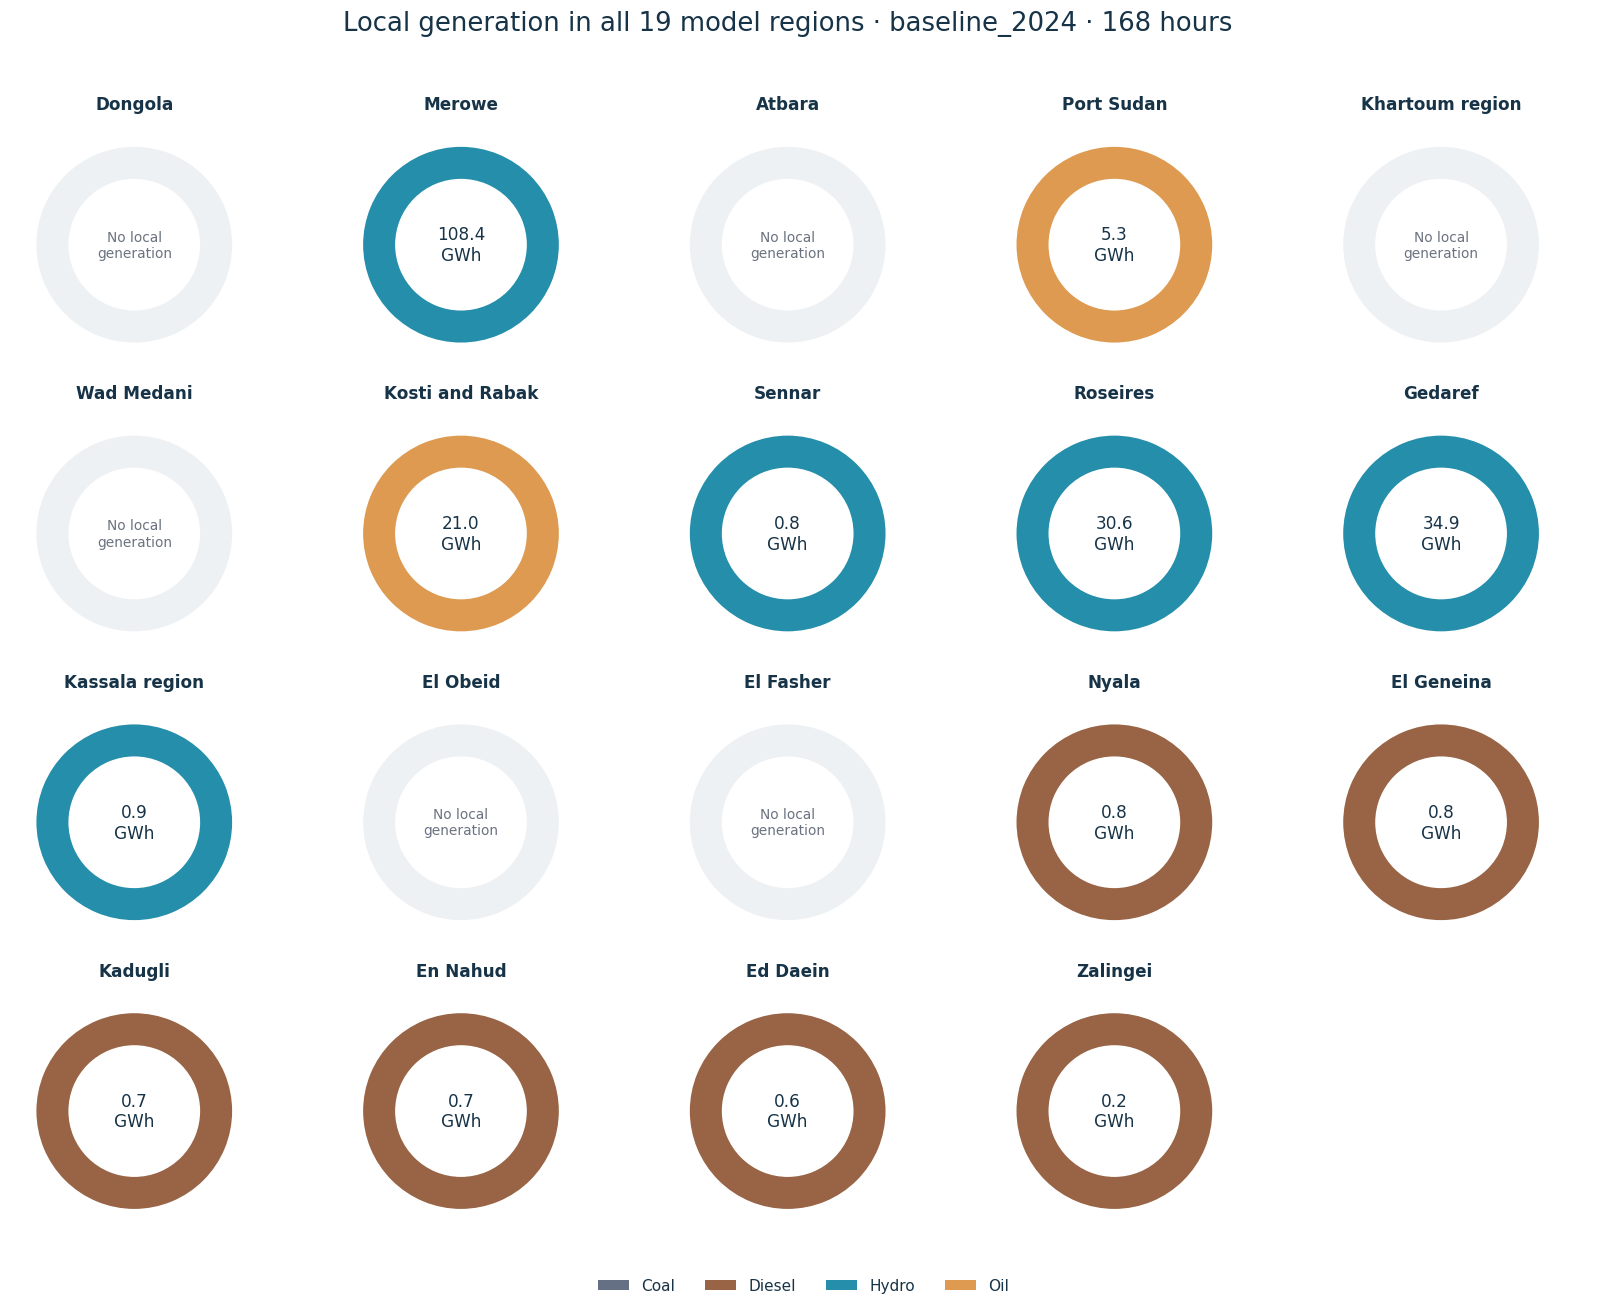

In [5]:
mix = (generation.unstack("carrier", fill_value=0)
       .reindex(n.buses.index, fill_value=0) / 1000)
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
for ax, bus in zip(axes.flat, n.buses.index):
    donut(ax, mix.loc[bus], regions.loc[bus,"label"], "GWh")
for ax in list(axes.flat)[len(n.buses):]:
    ax.axis("off")
fig.legend(handles=[Patch(facecolor=COLORS[c], label=LABELS[c]) for c in mix.columns],
           loc="lower center", ncol=len(mix.columns), frameon=False)
fig.suptitle(f"Local generation in all 19 model regions · {SCENARIO} · {len(n.snapshots)} hours", fontsize=17)
fig.tight_layout(rect=(0,.04,1,.96))
finish(fig, f"{SCENARIO}_regional_donuts")

## 5 · Regional service and shortages
These quantities come from synthetic regional demand and modelled dispatch. They must not be cited as observed outage rates. Regional shortage allocation can be non-unique when several regions have the same shortage penalty.

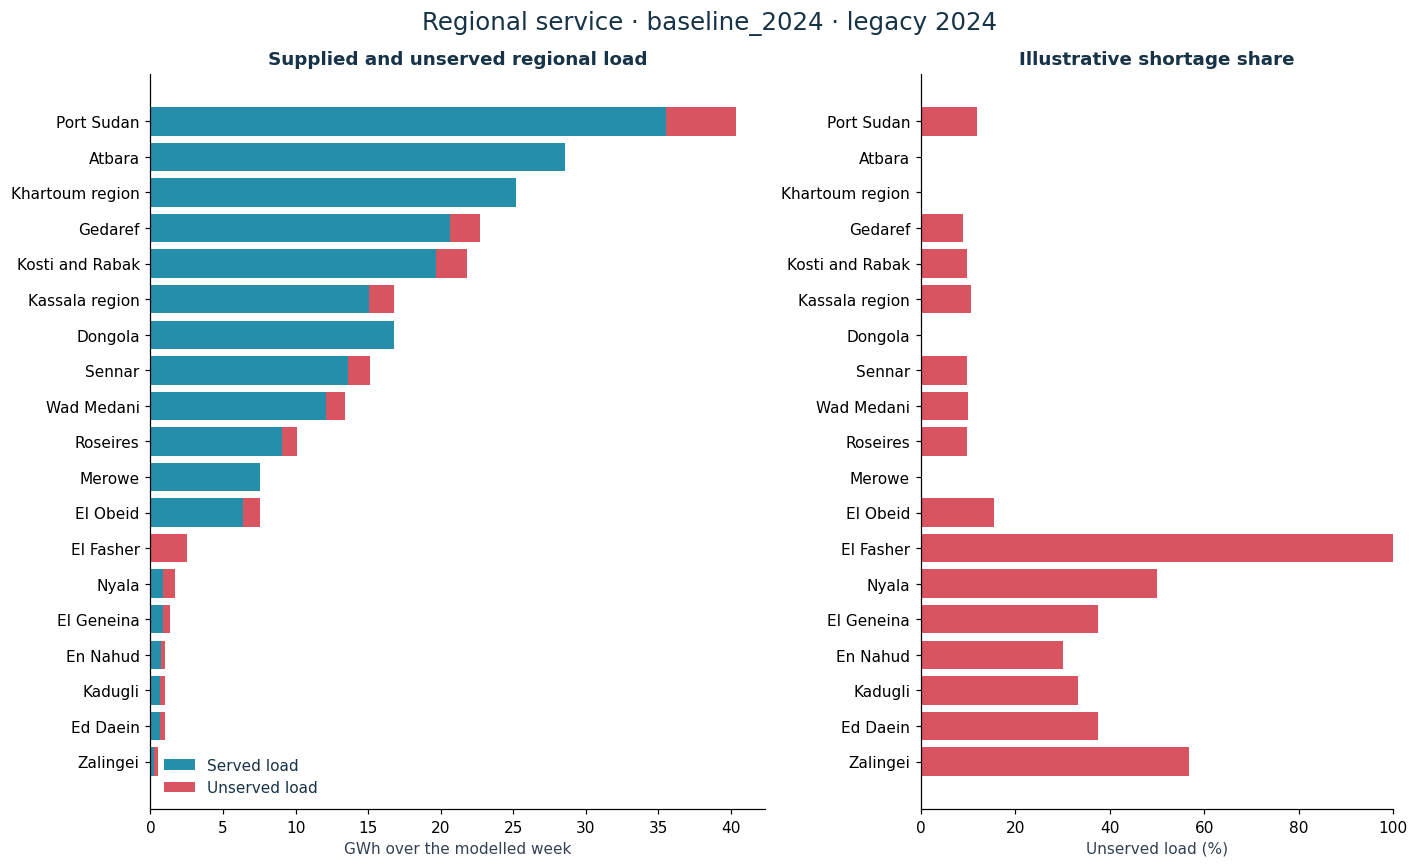

In [6]:
load_mwh = n.loads_t.p_set.mul(n.snapshot_weightings.generators, axis=0).sum()
unserved = g[g.carrier == "unserved"].assign(energy=energy_mwh).groupby("bus").energy.sum()
service = pd.DataFrame({"load_gwh":load_mwh/1000, "unserved_gwh":unserved/1000})
service["served_gwh"] = service.load_gwh - service.unserved_gwh
service["unserved_percent"] = 100*service.unserved_gwh/service.load_gwh
assert (service.served_gwh >= -1e-6).all()
service = service.sort_values("load_gwh")
fig, axes = plt.subplots(1,2,figsize=(13,8), gridspec_kw={"width_ratios":[1.3,1]})
axes[0].barh(service.index.map(regions.label), service.served_gwh, color="#258eaa", label="Served load")
axes[0].barh(service.index.map(regions.label), service.unserved_gwh, left=service.served_gwh,
             color=COLORS["unserved"], label="Unserved load")
axes[0].set(xlabel="GWh over the modelled week", title="Supplied and unserved regional load")
axes[0].legend(frameon=False)
axes[1].barh(service.index.map(regions.label), service.unserved_percent, color=COLORS["unserved"])
axes[1].set(xlabel="Unserved load (%)", xlim=(0,100), title="Illustrative shortage share")
fig.suptitle(f"Regional service · {SCENARIO} · legacy 2024", fontsize=16)
fig.tight_layout()
finish(fig, f"{SCENARIO}_regional_service")

## 6 · Inspect hourly dispatch in one region
Set `REGION` to a bus name, such as `Khartoum`, `PortSudan`, `Roseires` or `Nyala`, then rerun this cell.
Incoming domestic transfers are shown separately from local generation and cross-border imports. The stack includes a clearly marked shortage accounting variable; it balances local load plus outgoing transfers.

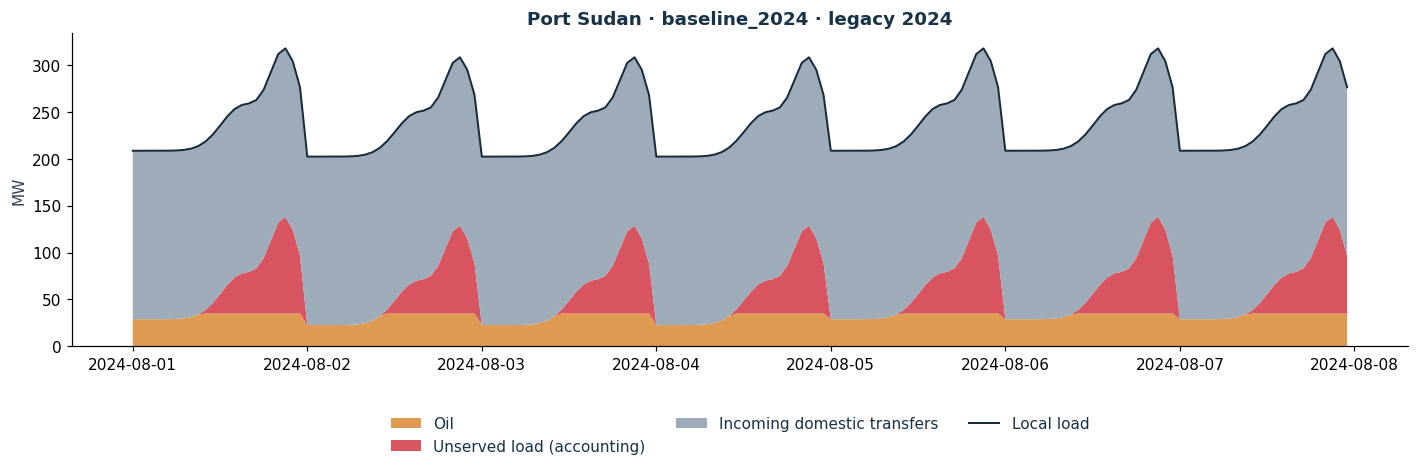

In [7]:
REGION = "PortSudan"
assert REGION in n.buses.index, list(n.buses.index)
local = g.index[g.bus == REGION]
dispatch = n.generators_t.p[local].T.groupby(g.loc[local,"carrier"]).sum().T.clip(lower=0)
incoming = pd.Series(0., index=n.snapshots)
outgoing = incoming.copy()
for name, link in n.links.iterrows():
    if link.bus0 == REGION:
        flow = n.links_t.p0[name]
    elif link.bus1 == REGION:
        flow = n.links_t.p1[name]
    else:
        continue
    incoming += (-flow).clip(lower=0)
    outgoing += flow.clip(lower=0)
dispatch["incoming"] = incoming
load = n.loads_t.p_set.loc[:, n.loads.bus == REGION].sum(axis=1)
np.testing.assert_allclose(dispatch.sum(axis=1), load+outgoing, atol=1e-5)
active = dispatch.columns[dispatch.max() > 1e-6]
fig, ax = plt.subplots(figsize=(13,4.5))
ax.stackplot(n.snapshots, *[dispatch[c] for c in active],
             labels=["Incoming domestic transfers" if c=="incoming" else
                     "Unserved load (accounting)" if c=="unserved" else LABELS[c] for c in active],
             colors=["#9eacb9" if c=="incoming" else COLORS[c] for c in active])
ax.plot(n.snapshots, load, color="#162c3b", lw=1.3, label="Local load")
if outgoing.max() > 1e-5:
    ax.plot(n.snapshots, load+outgoing, color="#162c3b", ls="--", label="Load + outgoing transfers")
ax.set(ylabel="MW", title=f"{regions.loc[REGION,'label']} · {SCENARIO} · legacy 2024")
ax.legend(loc="upper center", bbox_to_anchor=(.5,-.18), ncol=3, frameon=False)
fig.tight_layout()
finish(fig, f"{SCENARIO}_{REGION}_dispatch")

## 7 · Where do the six scenarios change service?
Each cell is modelled unserved demand as a percentage of regional demand. The repair case combines reconnection and increased transfer limits; it does not isolate the value of a single line.

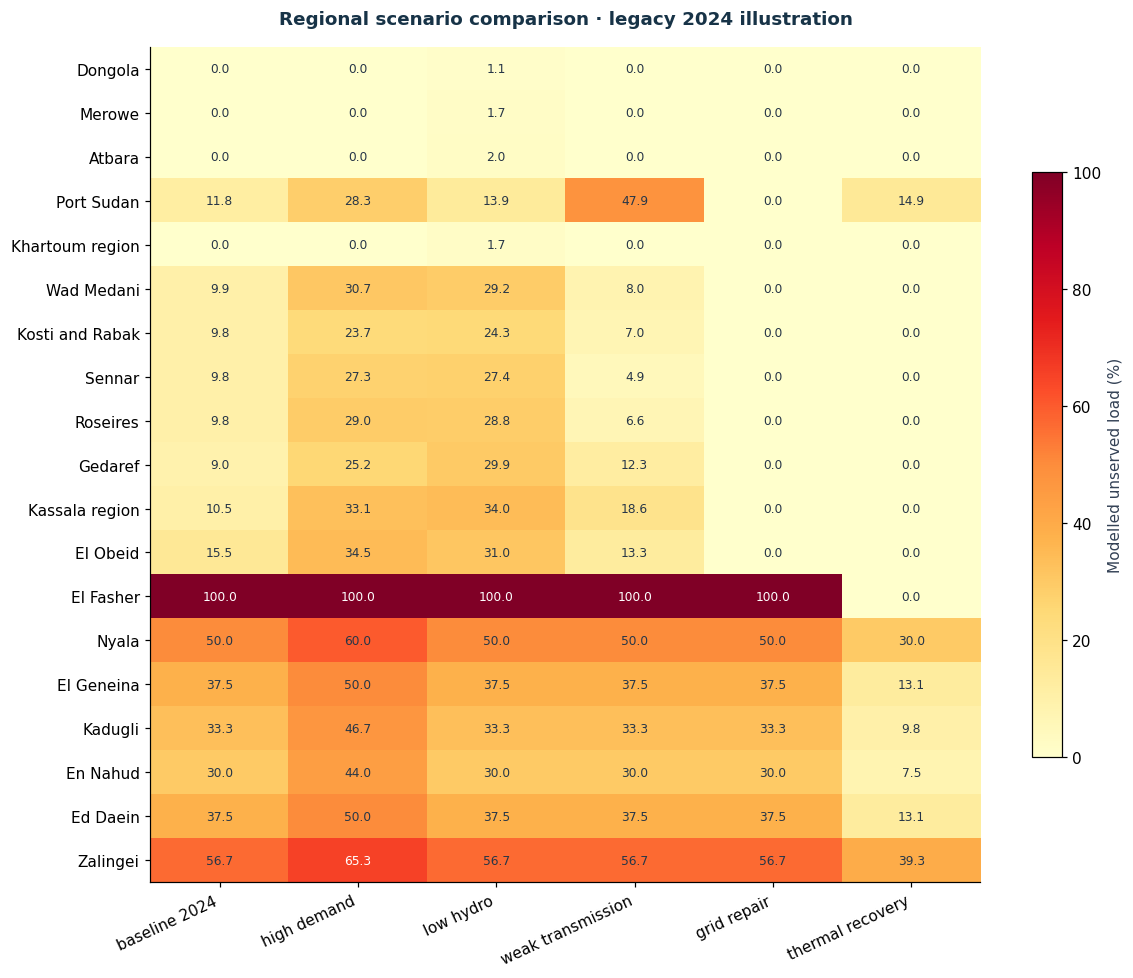

In [8]:
cases = list(json.loads((ROOT / "config/scenarios.json").read_text(encoding="utf-8")))
matrix = pd.DataFrame({case:pd.read_csv(ROOT / "results" / case / "regional_service.csv", index_col=0).unserved_fraction*100
                       for case in cases}).reindex(n.buses.index)
fig, ax = plt.subplots(figsize=(11,9))
im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(cases)), [c.replace("_"," ") for c in cases], rotation=25, ha="right")
ax.set_yticks(range(len(matrix)), matrix.index.map(regions.label))
for i in range(len(matrix)):
    for j in range(len(cases)):
        value = matrix.iloc[i,j]
        ax.text(j,i,f"{value:.1f}",ha="center",va="center",fontsize=8,
                color="white" if value>60 else "#273647")
fig.colorbar(im,ax=ax,label="Modelled unserved load (%)", shrink=.7)
ax.set_title("Regional scenario comparison · legacy 2024 illustration", pad=15)
fig.tight_layout()
finish(fig, "legacy_2024_scenario_heatmap")

## Keep the figures reproducible
- Figures are exported as PNG to `results/notebook_figures/`; notebooks keep embedded outputs.
- Capacity is MW; generation and service are GWh over 168 hours. No weekly result is annualized here.
- No regional 2022 values were inferred from the 2024 data. Reconstruct that year before using regional figures in the proposed historical paper.
- See [the data and methodology notes](../docs/REFERENCE_YEAR_2022.md) and [publication roadmap](../docs/PUBLICATION_ROADMAP.md).